In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

In [2]:
df = pd.read_csv("clauseiq_dataset.csv")

print(df.head())

                                         contract_id  \
0  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
1  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
2  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
3  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   
4  LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...   

                                         clause_text        category  
0                                Electric City Corp.         Parties  
1                   Electric City of Illinois L.L.C.         Parties  
2                      Electric City of Illinois LLC         Parties  
3                        7th day of September, 1999.  Agreement Date  
4  The term of this Agreement shall be ten (10) y...  Effective Date  


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (12204, 3)


In [4]:
df.sample(5)


,contract_id,clause_text,category
2420,"BELLRINGBRANDS,INC_02_07_2020-EX-10.18-MASTER ...","""Supplier"" or ""Fonterra""",Parties
11988,INGEVITYCORP_05_16_2016-EX-10.5-INTELLECTUAL P...,Subject to the terms and conditions of this Ag...,Irrevocable Or Perpetual License
9952,ALLIANCEBANCORPINCOFPENNSYLVANIA_10_18_2006-EX...,Greater Delaware Valley Holdings,Parties
8792,StaarSurgicalCompany_20180801_10-Q_EX-10.37_11...,STAAR shall pay for the return or replacement ...,Warranty Duration
7280,NeuroboPharmaceuticalsInc_20190903_S-4_EX-10.3...,Upon [***] days' notice and at time mutually a...,Audit Rights


In [5]:
print(df.columns)

Index(['contract_id', 'clause_text', 'category'], dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12204 entries, 0 to 12203
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   contract_id  12204 non-null  str  
 1   clause_text  12204 non-null  str  
 2   category     12204 non-null  str  
dtypes: str(3)
memory usage: 286.2 KB


In [7]:
df.describe(include='all')

,contract_id,clause_text,category
count,12204,12204,12204
unique,510,10549,41
top,"GOOSEHEADINSURANCE,INC_04_02_2018-EX-10.6-Fran...",STRATEGIC ALLIANCE AGREEMENT,Parties
freq,93,16,1251


In [8]:
print("Number of contracts:", df['contract_id'].nunique())
print("Number of clauses:", len(df))
print("Number of categories:", df['category'].nunique())

Number of contracts: 510
Number of clauses: 12204
Number of categories: 41


In [9]:
print(df['category'].unique())

<StringArray>
[                           'Parties',                     'Agreement Date',
                     'Effective Date',                    'Expiration Date',
                       'Renewal Term',                      'Governing Law',
                        'Exclusivity',            'No-Solicit Of Customers',
            'No-Solicit Of Employees',                     'Rofr/Rofo/Rofn',
                    'Anti-Assignment',                 'Price Restrictions',
                 'Minimum Commitment',                      'License Grant',
          'Post-Termination Services',                  'Warranty Duration',
                          'Insurance',                'Covenant Not To Sue',
                      'Document Name',                  'Change Of Control',
                       'Audit Rights',                 'Uncapped Liability',
                   'Cap On Liability', 'Notice Period To Terminate Renewal',
        'Termination For Convenience',                        

In [10]:
df['category'].nunique()

41

In [11]:
print(df.isnull().sum())

contract_id    0
clause_text    0
category       0
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
category_counts = df['category'].value_counts()

print(category_counts)

category
Parties                               1251
License Grant                          774
Cap On Liability                       672
Anti-Assignment                        652
Audit Rights                           642
Insurance                              559
Expiration Date                        467
Governing Law                          462
Post-Termination Services              449
Agreement Date                         426
Minimum Commitment                     424
Effective Date                         421
Revenue/Profit Sharing                 417
Exclusivity                            409
Rofr/Rofo/Rofn                         367
Ip Ownership Assignment                317
Document Name                          306
Non-Transferable License               295
Non-Compete                            257
Change Of Control                      253
Termination For Convenience            246
Renewal Term                           209
Warranty Duration                      175
Co

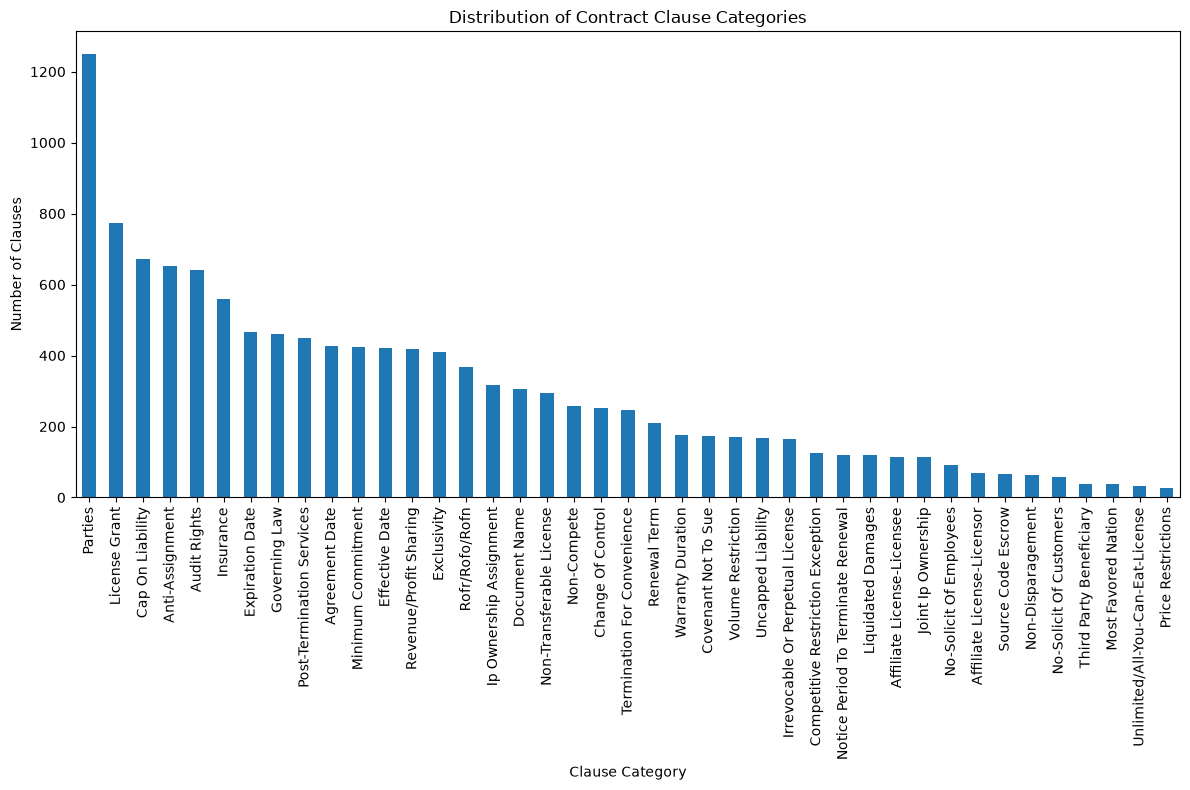

In [14]:
plt.figure(figsize=(12, 8))

category_counts.plot(kind='bar')

plt.title("Distribution of Contract Clause Categories")
plt.xlabel("Clause Category")
plt.ylabel("Number of Clauses")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [15]:
print(category_counts.head(10))

category
Parties                      1251
License Grant                 774
Cap On Liability              672
Anti-Assignment               652
Audit Rights                  642
Insurance                     559
Expiration Date               467
Governing Law                 462
Post-Termination Services     449
Agreement Date                426
Name: count, dtype: int64


In [16]:
df['word_count'] = df['clause_text'].apply(
    lambda x: len(str(x).split())
)

In [17]:
print(df['word_count'].describe())

count    12204.000000
mean        45.886431
std         43.661167
min          3.000000
25%         17.000000
50%         36.000000
75%         61.000000
max        479.000000
Name: word_count, dtype: float64


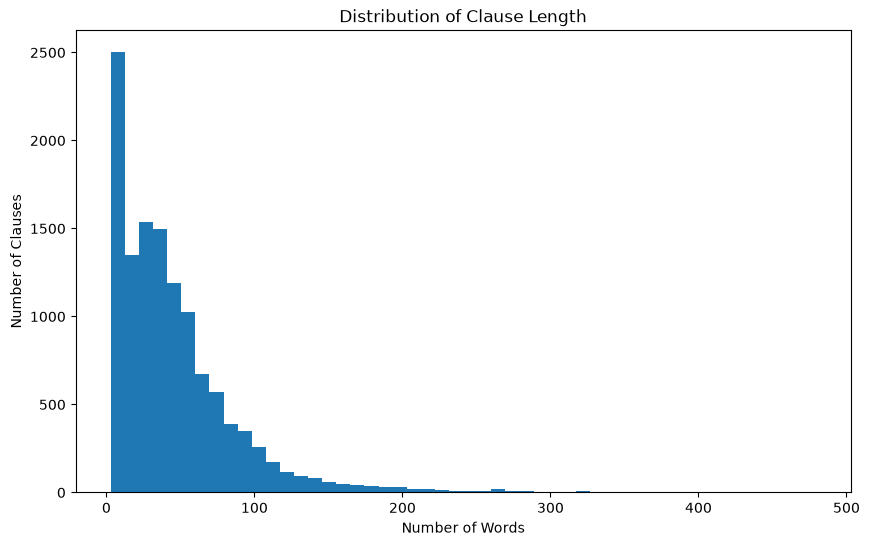

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df['word_count'], bins=50)

plt.title("Distribution of Clause Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Clauses")

plt.show()

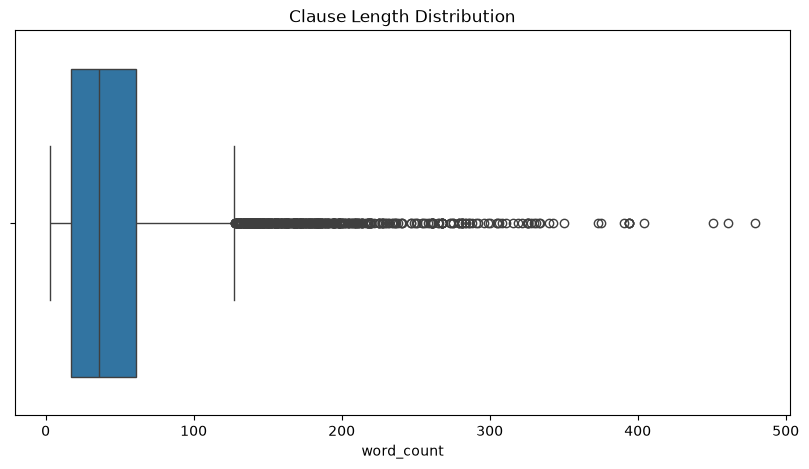

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['word_count'])

plt.title("Clause Length Distribution")

plt.show()

In [20]:
avg_length = (
    df.groupby('category')['word_count']
      .mean()
      .sort_values(ascending=False)
)

print(avg_length)

category
Affiliate License-Licensor            95.347826
Affiliate License-Licensee            85.069565
Irrevocable Or Perpetual License      83.006061
Most Favored Nation                   72.368421
Source Code Escrow                    71.338462
Uncapped Liability                    70.784431
Post-Termination Services             70.345212
Competitive Restriction Exception     68.137097
License Grant                         64.753230
Non-Disparagement                     64.281250
Rofr/Rofo/Rofn                        64.016349
Ip Ownership Assignment               63.561514
Covenant Not To Sue                   63.369942
No-Solicit Of Employees               62.945055
Non-Transferable License              62.593220
Non-Compete                           61.186770
Change Of Control                     61.063241
Liquidated Damages                    59.107438
Cap On Liability                      58.994048
Price Restrictions                    56.814815
Exclusivity                    

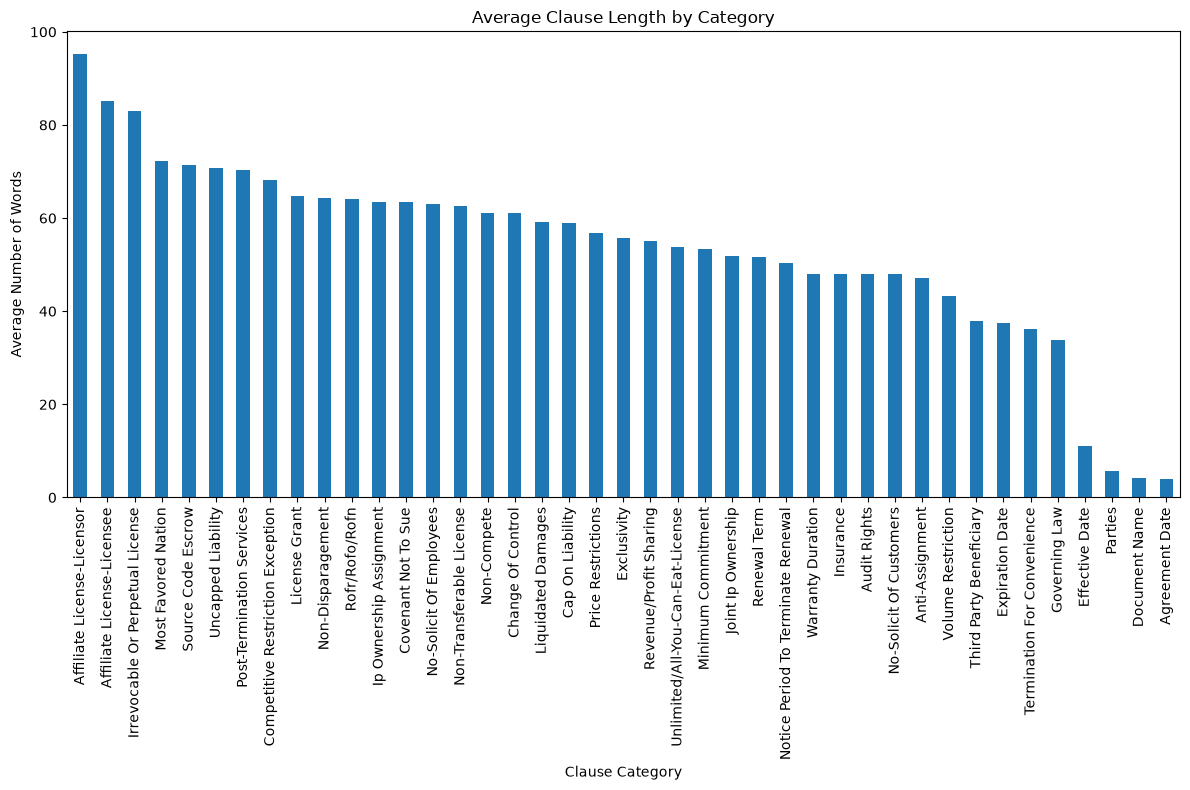

In [21]:
plt.figure(figsize=(12, 8))

avg_length.plot(kind='bar')

plt.title("Average Clause Length by Category")
plt.xlabel("Clause Category")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [22]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [23]:
df['clean_text'] = df['clause_text'].apply(clean_text)

In [24]:
all_words = ' '.join(df['clean_text']).split()

In [25]:
word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('the', 37890), ('of', 24666), ('to', 21266), ('and', 18287), ('or', 15505), ('in', 12417), ('any', 8764), ('agreement', 7686), ('a', 7555), ('shall', 7352), ('this', 7064), ('for', 6807), ('by', 5307), ('such', 5074), ('with', 5044), ('be', 5009), ('party', 4686), ('as', 4356), ('s', 3876), ('that', 3682)]


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

ModuleNotFoundError: No module named 'nltk'

In [1]:
import sys

print(sys.executable)

d:\SOFINS\Github\ClauseIQ\.venv\Scripts\python.exe
